# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here


In [2]:
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'tests' / 'common' / 'process_profiles_lib.py').is_file():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate tests/common/process_profiles_lib.py from current notebook path')

lib_dir = repo_root / 'tests' / 'common'
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

from process_profiles_lib import (
    SUM_FIELDS,
    build_policy_summary,
    extract_job_id,
    find_stdout_for_job,
    list_profiles,
    load_likwid_profile,
    newest_profile_for_benchmark,
    plot_benchmark_boxplots,
    plot_likwid_timeseries,
    print_policy_context,
    run_has_fatal_error,
    summarize_profile,
)


In [3]:
per_benchmark_summary, all_output = build_policy_summary(
    base_dir=base_dir,
    subfolder_pattern=subfolder_pattern,
    benchmark_name=benchmark_name,
    skip_initial=skip_initial,
    output_dir=output_dir,
    policy_name=policy_name,
)

print_policy_context(policy_name, subfolder_pattern, benchmark_name)
all_output


Removed 31 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 3 extreme-high LIKWID samples using automatic power filtering
Skipping 2.25GHz-0/fotonik3d: found fatal error markers in speccpu_fotonik3d.37778.prof
Removed 1 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Removed 12 extreme-high LIKWID samples using automatic power filtering
Removed 39 extreme-high LIKWID samples using automatic power filtering
Removed 5 extreme-high LIKWID samples using automatic power filtering
Skipping 2.25GHz-0/perlbench: found fatal error markers in speccpu_perlbench.37784.out
Removed 38 extreme-high LIKWID samples using automatic power filtering
Removed 65 extreme-high LIKWID samples using automatic power filtering
Skipping 2.25GHz-0/x264: found fatal error markers in speccpu_x264.37787.prof
Skipping 2.25GHz-0/xalancbmk: found fatal 

,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,2.25GHz-0,cam4,3853.33,552.27,2127271.73,8.197088e+09
1,2.25GHz-1,cam4,3834.66,523.70,2007590.63,7.698434e+09
2,2.25GHz-2,cam4,3849.78,532.10,2047694.23,7.883166e+09
3,2.25GHz-3,cam4,3843.53,533.36,2049314.57,7.876612e+09
4,2.25GHz-4,cam4,3836.66,528.18,2025961.84,7.772919e+09
...,...,...,...,...,...,...
60,2.25GHz-1,xz,2168.32,474.96,1031132.37,2.235830e+09
61,2.25GHz-2,xz,2180.64,478.83,1045987.84,2.280924e+09
62,2.25GHz-3,xz,2189.15,473.73,1039406.40,2.275415e+09
63,2.25GHz-4,xz,2162.31,480.61,1041541.57,2.252133e+09


Removed 31 extreme-high samples from 'Power L3 [W]' using upper bound 938


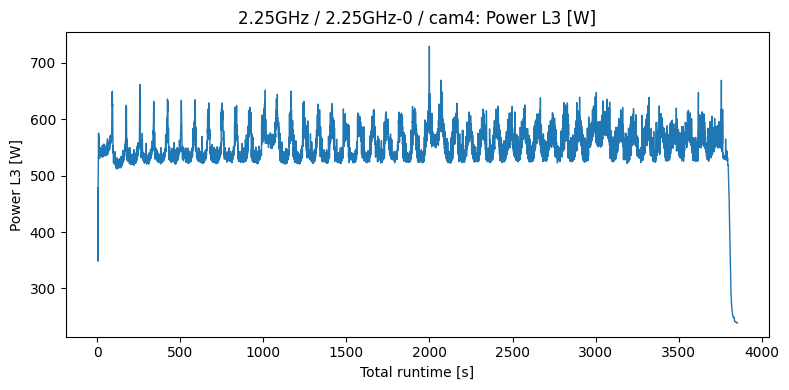

In [4]:
# Plot LIKWID sample time-series for one subfolder/benchmark and one field
selected_subfolder = '2.25GHz-0'
selected_benchmark = None  # None => auto-pick first benchmark found in selected_subfolder
selected_field = 'Power L3 [W]'

plot_likwid_timeseries(
    base_dir=base_dir,
    selected_subfolder=selected_subfolder,
    selected_benchmark=selected_benchmark,
    selected_field=selected_field,
    skip_initial=skip_initial,
    policy_name=policy_name,
    include_benchmark_in_title=True,
)


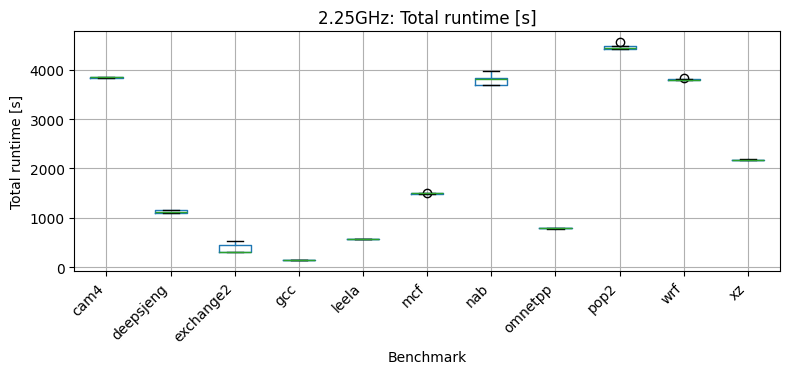

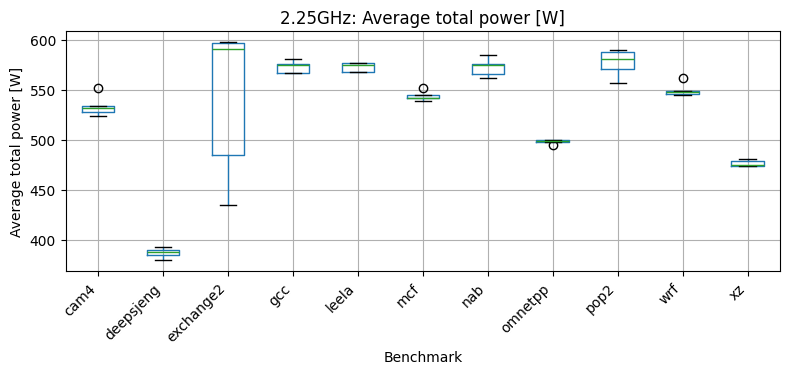

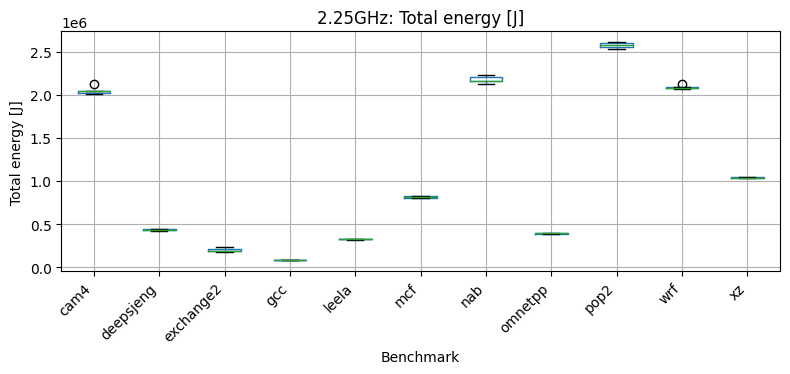

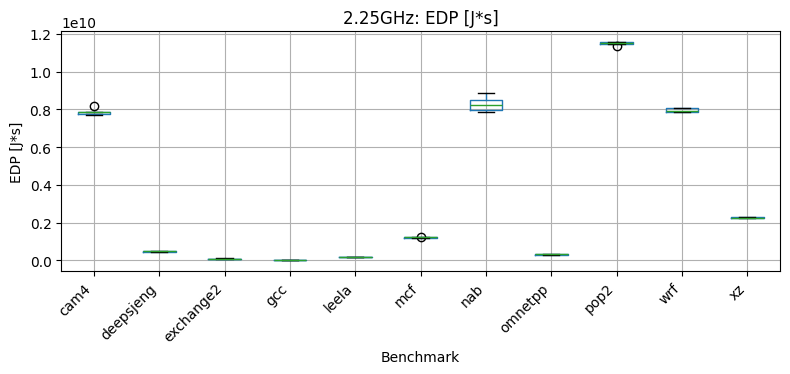

In [5]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

plot_benchmark_boxplots(
    per_benchmark_summary=per_benchmark_summary,
    policy_name=policy_name,
    plot_metrics=plot_metrics,
)
